<a href="https://colab.research.google.com/github/Parth4210/machine-learning-foundations/blob/main/SpotifyAnalysis2024.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importing the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

In [ ]:
# Uploading the dataset
uploaded = files.upload()

Saving Most Streamed Spotify Songs 2024.csv to Most Streamed Spotify Songs 2024 (1).csv


In [ ]:
# Loading the dataset
filepath = "/content/Most Streamed Spotify Songs 2024.csv"
spotify_data = pd.read_csv(filepath, encoding='latin1')

In [ ]:
# Reviewing the dataset
spotify_data.head()

,Track,Album Name,Artist,Release Date,ISRC,All Time Rank,Track Score,Spotify Streams,Spotify Playlist Count,Spotify Playlist Reach,...,SiriusXM Spins,Deezer Playlist Count,Deezer Playlist Reach,Amazon Playlist Count,Pandora Streams,Pandora Track Stations,Soundcloud Streams,Shazam Counts,TIDAL Popularity,Explicit Track
0,MILLION DOLLAR BABY,Million Dollar Baby - Single,Tommy Richman,4/26/2024,QM24S2402528,1,725.4,"390,470,936","30,716","196,631,588",...,684,62.0,"17,598,718",114.0,"18,004,655","22,931","4,818,457","2,669,262",NaN,0
1,Not Like Us,Not Like Us,Kendrick Lamar,5/4/2024,USUG12400910,2,545.9,"323,703,884","28,113","174,597,137",...,3,67.0,"10,422,430",111.0,"7,780,028","28,444","6,623,075","1,118,279",NaN,1
2,i like the way you kiss me,I like the way you kiss me,Artemas,3/19/2024,QZJ842400387,3,538.4,"601,309,283","54,331","211,607,669",...,536,136.0,"36,321,847",172.0,"5,022,621","5,639","7,208,651","5,285,340",NaN,0
3,Flowers,Flowers - Single,Miley Cyrus,1/12/2023,USSM12209777,4,444.9,"2,031,280,633","269,802","136,569,078",...,"2,182",264.0,"24,684,248",210.0,"190,260,277","203,384",NaN,"11,822,942",NaN,0
4,Houdini,Houdini,Eminem,5/31/2024,USUG12403398,5,423.3,"107,034,922","7,223","151,469,874",...,1,82.0,"17,660,624",105.0,"4,493,884","7,006","207,179","457,017",NaN,1


In [ ]:
# Checking for missing values
spotify_data.isnull().sum()

,0
Track,0
Album Name,0
Artist,5
Release Date,0
ISRC,0
All Time Rank,0
Track Score,0
Spotify Streams,113
Spotify Playlist Count,70
Spotify Playlist Reach,72


In [ ]:
# Checking the number of rows and columns in the dataset
spotify_data.shape

(4600, 29)

In [ ]:
# Handling the missing data
# spotify_data.drop(columns=['TIDAL Popularity'], inplace=True) - all the rows were empty

# spotify_data.dropna(subset=['Artist'], inplace=True) - removed all rows with no artists

# Fixing all the data by replacing their null values with unknown, and taking all the rows that are required
spotify_data = spotify_data.fillna("Unknown")
spotify_data = spotify_data.iloc[:,0:11]

In [ ]:
# Again verifying for the null values
spotify_data.isnull().sum()


,0
Track,0
Album Name,0
Artist,0
Release Date,0
ISRC,0
All Time Rank,0
Track Score,0
Spotify Streams,0
Spotify Playlist Count,0
Spotify Playlist Reach,0


It is fixed now we can begin with creating of graphs and analyzing the data


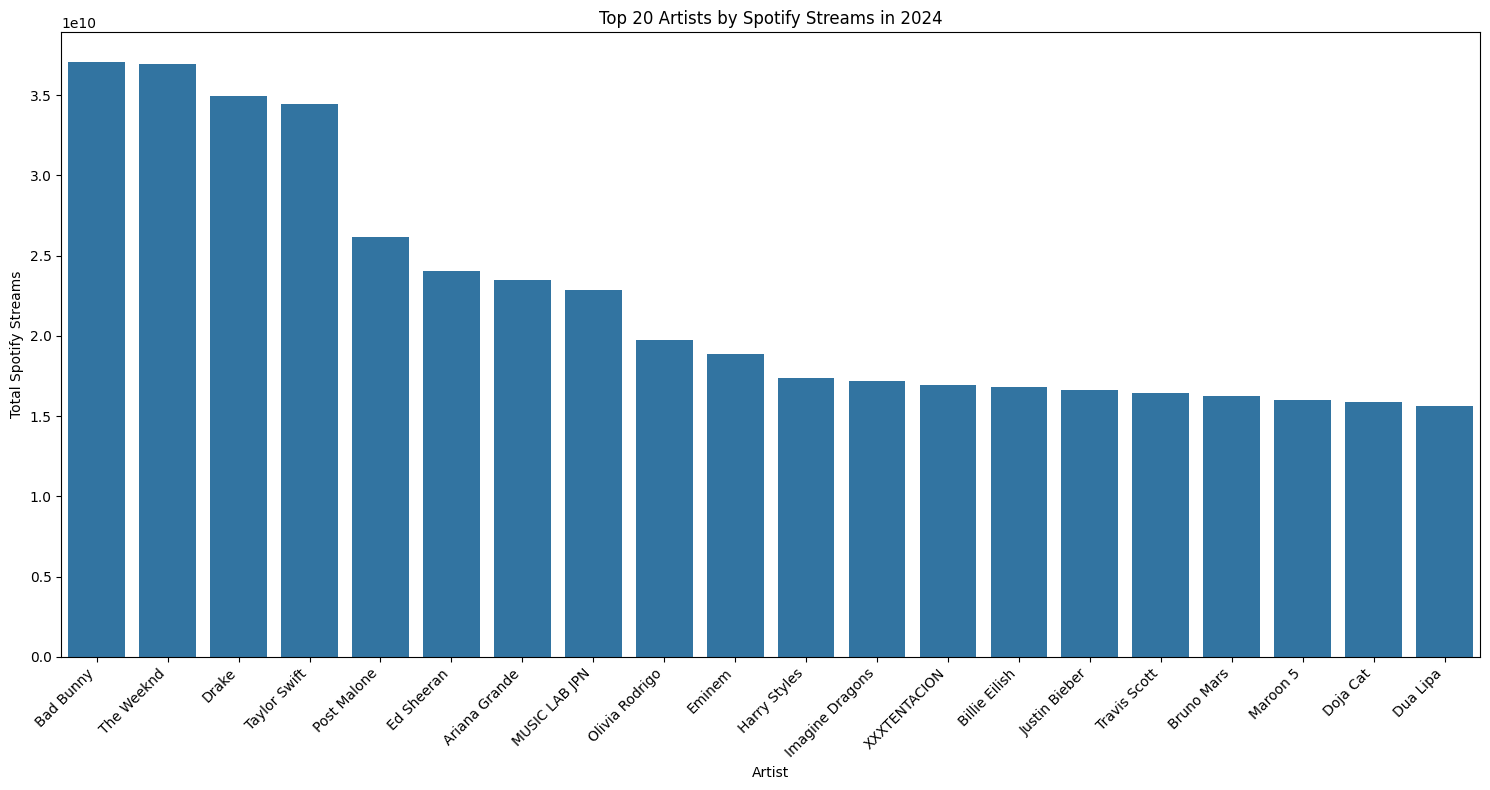

In [ ]:
# Making a bar graph to check which artist has the highest amount of streams

# Convert 'Spotify Streams' to numeric, handling 'Unknown' and commas
spotify_data['Spotify Streams'] = spotify_data['Spotify Streams'].astype(str).str.replace(',', '', regex=False)
spotify_data['Spotify Streams'] = spotify_data['Spotify Streams'].replace('Unknown', np.nan).astype(float)
spotify_data['Spotify Streams'] = spotify_data['Spotify Streams'].fillna(0) # Fill NaN with 0 for plotting

# Group by artist and sum the streams, then get the top N artists
top_artists = spotify_data.groupby('Artist')['Spotify Streams'].sum().nlargest(20).reset_index()

plt.figure(figsize=(15, 8))
sns.barplot(x=top_artists["Artist"], y=top_artists["Spotify Streams"])
plt.title("Top 20 Artists by Spotify Streams in 2024")
plt.xlabel("Artist")
plt.ylabel("Total Spotify Streams")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Index(['Track', 'Album Name', 'Artist', 'Release Date', 'ISRC',
       'All Time Rank', 'Track Score', 'Spotify Streams',
       'Spotify Playlist Count', 'Spotify Playlist Reach',
       'Spotify Popularity'],
      dtype='object')


/tmp/ipykernel_18955/939487425.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  sns.regplot(x=spotify_data["Track Score"].replace('Unknown', np.nan).astype(float).fillna(0), y=spotify_data["Spotify Popularity"].replace('Unknown', np.nan).astype(float).fillna(0))


Text(0, 0.5, 'Spotify popularity')

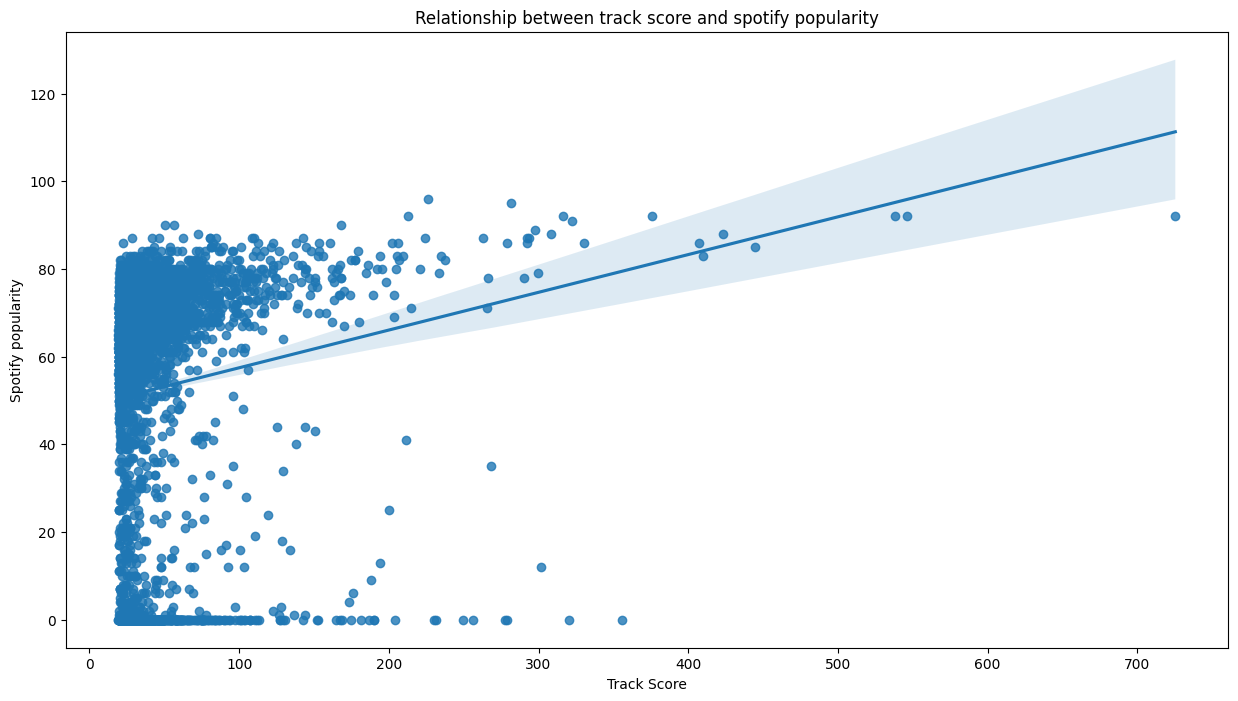

In [ ]:
# Creating a scatter plot to analyze the relationship between track score and spotify popularity
print(spotify_data.columns)
plt.figure(figsize=(15, 8))
sns.regplot(x=spotify_data["Track Score"].replace('Unknown', np.nan).astype(float).fillna(0), y=spotify_data["Spotify Popularity"].replace('Unknown', np.nan).astype(float).fillna(0))
plt.title("Relationship between track score and spotify popularity")
plt.xlabel("Track Score")
plt.ylabel("Spotify popularity")

The regression line shows that as the track score increases the popularity of the song also increases along with it due to the positive correlation shown by the plot.


Text(158.22222222222223, 0.5, 'Features')

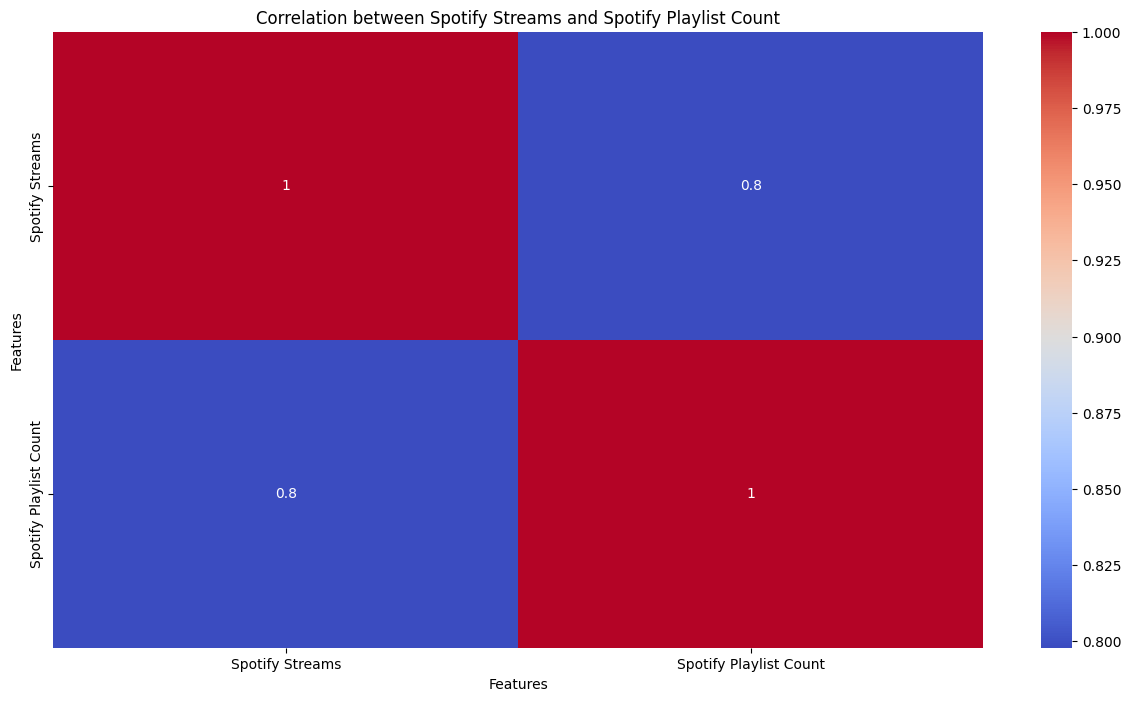

In [ ]:
# Creating a heatmap to find relationship between spotify playlist count and spotify streams
heatmap_df = spotify_data.iloc[:,[7,8]].copy() # Use .copy() to avoid SettingWithCopyWarning

# Convert 'Spotify Playlist Count' to numeric, handling 'Unknown' and commas
heatmap_df['Spotify Playlist Count'] = heatmap_df['Spotify Playlist Count'].astype(str).str.replace(',', '', regex=False)
heatmap_df['Spotify Playlist Count'] = heatmap_df['Spotify Playlist Count'].replace('Unknown', np.nan).astype(float)
heatmap_df['Spotify Playlist Count'] = heatmap_df['Spotify Playlist Count'].fillna(0)

plt.figure(figsize=(15, 8))
sns.heatmap(data=heatmap_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation between Spotify Streams and Spotify Playlist Count")
plt.xlabel("Features")
plt.ylabel("Features")